# VTA Ridership — ML Regression: Predict Route-Level Boardings

**Task:** Predict total boardings per route for a given time period and service day.

**Target:** `TOTAL_BOARDINGS` per route-time-period combination (aggregated from stop-level data)

**Models:** Linear Regression → Lasso Regression → Random Forest → XGBoost

**6 Visualizations:** Predicted vs Actual, Residual Distribution, Feature Importance, SHAP, Correlation Heatmap, Model Comparison

---

In [1]:
!pip install pandas openpyxl numpy scikit-learn xgboost shap matplotlib seaborn

import pandas as pd
import numpy as np
import time
import datetime
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='colorblind')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import shap

print('All imports loaded successfully.')

All imports loaded successfully.


## Step 1: Load & Clean Data

Reusing the same cleaning pipeline from the EDA dashboard notebook.

In [2]:
start = time.time()
df_raw = pd.read_excel('OCT_2025_RBS_FULL_DATA_SET.XLSX', engine='openpyxl')
print(f'Loaded in {time.time() - start:.1f}s | Shape: {df_raw.shape}')

start_clean = time.time()
df = df_raw.copy()
df = df.dropna(how='all').dropna(axis=1, how='all')

numeric_cols = ['BOARDINGS', 'ALIGHTINGS', 'TRIPS', 'AVG_BOARDINGS', 'AVG_ALIGHTINGS',
    'AVG_ACTIVITY', 'PASS_LOAD', 'PEAK_LOAD', 'AVG_PEAK_LOAD',
    'SORT_ORDER', 'STOP_ID', 'TOTAL_SORT', 'SORT_SP']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

str_cols = ['ROUTE_NAME', 'ROUTE_NUMBER', 'SERVICE_PERIOD', 'SERVICE_CODE',
    'DIRECTION_NAME', 'BRANCH', 'MAIN_CROSS_STREET', 'CITY',
    'STOP_DISPLAY', 'Additional_Notes', 'PATTERN_KEY', 'BLOCK']
for col in str_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan})

def trip_time_to_hour(val):
    if isinstance(val, datetime.time): return val.hour
    try: return int(round(float(val) * 24)) % 24
    except (TypeError, ValueError): return np.nan

df['TRIP_HOUR'] = df['TRIP_TIME'].apply(trip_time_to_hour).astype('Int64')
df['CITY'] = df['CITY'].fillna('Unknown')
df['Additional_Notes'] = df['Additional_Notes'].fillna('None')
for col in ['BOARDINGS', 'ALIGHTINGS', 'AVG_BOARDINGS', 'AVG_ALIGHTINGS', 'AVG_ACTIVITY']:
    if col in df.columns: df[col] = df[col].fillna(0)

def classify_route(sc):
    if pd.isna(sc): return 'Unknown'
    sc = str(sc).lower()
    if 'express' in sc: return 'Express'
    elif 'frequent' in sc: return 'Frequent'
    elif 'local' in sc: return 'Local'
    elif 'light rail' in sc or 'lrt' in sc: return 'Light Rail'
    elif 'rapid' in sc: return 'Rapid'
    return 'Other'

df['ROUTE_TYPE'] = df['SERVICE_CODE'].apply(classify_route)

def categorize_time(h):
    if pd.isna(h): return 'Unknown'
    h = int(h)
    if 5 <= h < 9: return 'AM Peak (5-9)'
    elif 9 <= h < 15: return 'Midday (9-3)'
    elif 15 <= h < 19: return 'PM Peak (3-7)'
    elif 19 <= h < 23: return 'Evening (7-11)'
    return 'Late Night (11-5)'

df['TIME_PERIOD'] = df['TRIP_HOUR'].apply(categorize_time)
df['TOTAL_ACTIVITY'] = df['BOARDINGS'] + df['ALIGHTINGS']
df = df.drop_duplicates()
print(f'Cleaning complete in {time.time() - start_clean:.2f}s | Final shape: {df.shape}')

Loaded in 33.3s | Shape: (388202, 32)
Cleaning complete in 3.50s | Final shape: (382720, 36)


## EDA-to-ML Bridge: Why Regression?

Our EDA dashboard (Tab 1 — **WHERE: Stops & Cities**) revealed massive variance in boardings:
- **Palo Alto Transit Center** has 30,000+ total boardings while most stops have under 1,000
- The **city-level treemap** shows San Jose dominates ridership by a wide margin
- Tab 2 (**WHEN**) revealed strong **weekday vs. weekend** and **peak-hour** patterns affecting boarding volumes

This motivates a **regression model** to predict total boardings at the **route level** — aggregated by route, time period, and service day. This is the natural unit for VTA scheduling decisions: "How many total passengers will Route 22 carry during AM Peak on a Weekday?"

**Why route-level instead of stop-level?** Stop-level boardings depend heavily on stop identity (3,000+ unique stops), which our features cannot capture. Route-level aggregation lets the model focus on patterns that are actionable for scheduling — route type, time of day, and service period.

**Data leakage prevention:** We do NOT use ALIGHTINGS, TOTAL_ACTIVITY, or PEAK_LOAD as features.

In [3]:
print('=== Feature Engineering for Regression (Route-Level) ===\n')

# Aggregate to route-level: total boardings per route × time period × service period
agg_cols = ['ROUTE_NUMBER', 'ROUTE_TYPE', 'TIME_PERIOD', 'SERVICE_PERIOD']
df_route = (
    df.dropna(subset=['BOARDINGS'])
    .groupby(agg_cols, observed=True)
    .agg(
        TOTAL_BOARDINGS=('BOARDINGS', 'sum'),
        AVG_TRIP_HOUR=('TRIP_HOUR', 'mean'),
        NUM_STOPS=('STOP_ID', 'nunique'),
        NUM_TRIPS=('TRIPS', 'sum'),
    )
    .reset_index()
)
df_route = df_route[df_route['TOTAL_BOARDINGS'] > 0]
print(f'Route-level rows: {len(df_route):,} (aggregated from {len(df):,} stop-level rows)')
print(f'\nTarget statistics (TOTAL_BOARDINGS per route-time-period):')
print(df_route['TOTAL_BOARDINGS'].describe())

reg_features = ['ROUTE_NUMBER', 'ROUTE_TYPE', 'TIME_PERIOD',
                'SERVICE_PERIOD', 'AVG_TRIP_HOUR', 'NUM_STOPS']

df_enc = df_route[reg_features + ['TOTAL_BOARDINGS']].dropna().copy()
reg_encoders = {}
for col in ['ROUTE_NUMBER', 'ROUTE_TYPE', 'TIME_PERIOD', 'SERVICE_PERIOD']:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    reg_encoders[col] = le
    print(f'  Encoded {col}: {len(le.classes_)} unique values')

X = df_enc[reg_features].astype(float)
y = df_enc['TOTAL_BOARDINGS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

=== Feature Engineering for Regression (Route-Level) ===

Route-level rows: 505 (aggregated from 382,720 stop-level rows)

Target statistics (TOTAL_BOARDINGS per route-time-period):
count      505.000000
mean      3375.536634
std       5871.279221
min          7.000000
25%        323.000000
50%       1077.000000
75%       3375.000000
max      42508.000000
Name: TOTAL_BOARDINGS, dtype: float64
  Encoded ROUTE_NUMBER: 60 unique values
  Encoded ROUTE_TYPE: 7 unique values
  Encoded TIME_PERIOD: 5 unique values
  Encoded SERVICE_PERIOD: 3 unique values

Train: 404 | Test: 101


## Step 2: Train Regression Models

Training 4 models: Linear Regression (baseline) → Lasso (L1 regularized, feature selection) → Random Forest (bagging) → XGBoost (boosting).

In [4]:
print('=== Training 4 Regression Models ===\n')
start_ml = time.time()
results = {}

models = {
    'Linear Regression': (LinearRegression(), True),
    'Lasso Regression': (Lasso(alpha=1.0, random_state=42), True),
    'Random Forest': (RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1), False),
    'XGBoost': (XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, tree_method='hist'), False),
}

for name, (model, use_scaled) in models.items():
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled if use_scaled else X_test
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    if use_scaled:
        y_pred = np.clip(y_pred, 0, None)
    results[name] = {
        'model': model, 'y_pred': y_pred,
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'mae': mean_absolute_error(y_test, y_pred),
        'r2': r2_score(y_test, y_pred), 'scaled': use_scaled,
    }
    print(f'{name:<25} RMSE: {results[name]["rmse"]:.3f}  '
          f'MAE: {results[name]["mae"]:.3f}  R2: {results[name]["r2"]:.4f}')

# Show Lasso feature selection
lasso_model = results['Lasso Regression']['model']
lasso_coefs = pd.Series(lasso_model.coef_, index=reg_features)
kept = (lasso_coefs != 0).sum()
dropped = (lasso_coefs == 0).sum()
print(f'\nLasso feature selection: {kept} features kept, {dropped} features dropped')
if dropped > 0:
    print(f'  Dropped: {lasso_coefs[lasso_coefs == 0].index.tolist()}')
print(f'  Coefficients: {dict(zip(reg_features, [f"{c:.2f}" for c in lasso_coefs]))}')

best_name = min(results, key=lambda k: results[k]['rmse'])
best = results[best_name]
ml_time = time.time() - start_ml
print(f'\nBest model: {best_name} (RMSE: {best["rmse"]:.3f}, R2: {best["r2"]:.4f})')
print(f'Training complete in {ml_time:.1f}s')

=== Training 4 Regression Models ===

Linear Regression         RMSE: 3894.099  MAE: 3077.308  R2: 0.0203
Lasso Regression          RMSE: 3893.405  MAE: 3077.256  R2: 0.0206
Random Forest             RMSE: 1618.991  MAE: 976.722  R2: 0.8307
XGBoost                   RMSE: 1477.474  MAE: 796.073  R2: 0.8590

Lasso feature selection: 6 features kept, 0 features dropped
  Coefficients: {'ROUTE_NUMBER': '-358.37', 'ROUTE_TYPE': '-649.20', 'TIME_PERIOD': '1337.62', 'SERVICE_PERIOD': '2514.57', 'AVG_TRIP_HOUR': '-1044.05', 'NUM_STOPS': '1821.52'}

Best model: XGBoost (RMSE: 1477.474, R2: 0.8590)
Training complete in 1.0s


## Step 3: ML Visualizations (6 Total)

Each visualization includes a transit-relevant interpretation. All plots are saved to the `figures/` folder for use in slides and the report.

### Visualization 1: Predicted vs Actual

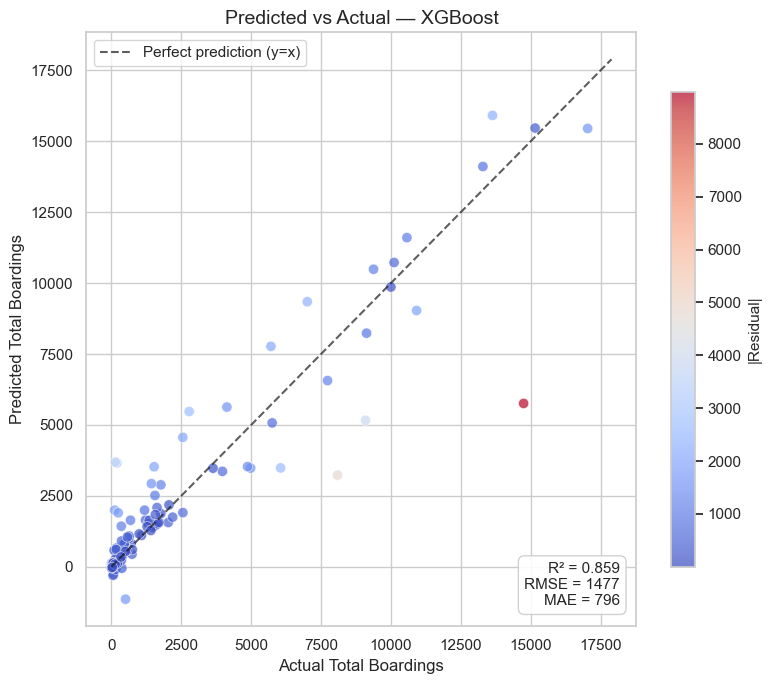

In [5]:
import os
os.makedirs('figures', exist_ok=True)

actual = y_test.values
predicted = best['y_pred']
residuals_scatter = np.abs(actual - predicted)

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(actual, predicted, alpha=0.7, s=55, c=residuals_scatter,
                     cmap='coolwarm', edgecolors='white', linewidth=0.5)
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('|Residual|', fontsize=11)

max_val = max(actual.max(), predicted.max()) * 1.05
ax.plot([0, max_val], [0, max_val], 'k--', lw=1.5, alpha=0.7, label='Perfect prediction (y=x)')
ax.set_xlabel('Actual Total Boardings', fontsize=12)
ax.set_ylabel('Predicted Total Boardings', fontsize=12)
ax.set_title(f'Predicted vs Actual — {best_name}', fontsize=14)
ax.legend(fontsize=11, loc='upper left')

stats_text = f'R² = {best["r2"]:.3f}\nRMSE = {best["rmse"]:.0f}\nMAE = {best["mae"]:.0f}'
ax.text(0.97, 0.03, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#cccccc', alpha=0.9))

plt.tight_layout()
plt.savefig('figures/reg_1_predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

**Transit Insight:** Points close to the red diagonal indicate accurate predictions. Points below the line mean the model **underestimates** route-level boardings — these are routes/time periods where demand is higher than predicted, potentially requiring more vehicles. Points above the line mean the model **overestimates**, suggesting VTA could reallocate resources elsewhere.

### Visualization 2: Residual Distribution

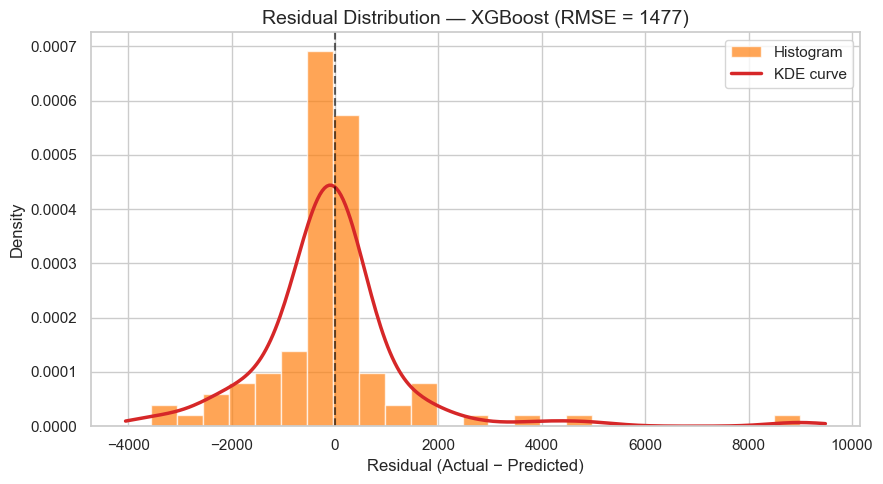

Residual stats:  Mean=-74.3  Median=-65.8  Std=1475.6


In [6]:
residuals = actual - predicted

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(residuals, bins=25, color='#ff7f0e', alpha=0.7, edgecolor='white', density=True, label='Histogram')

from scipy.stats import gaussian_kde
kde_x = np.linspace(residuals.min() - 500, residuals.max() + 500, 300)
kde = gaussian_kde(residuals)
ax.plot(kde_x, kde(kde_x), color='#d62728', lw=2.5, label='KDE curve')

ax.axvline(x=0, color='black', linestyle='--', lw=1.5, alpha=0.6)
ax.set_xlabel('Residual (Actual − Predicted)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Residual Distribution — {best_name} (RMSE = {best["rmse"]:.0f})', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figures/reg_2_residual_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Residual stats:  Mean={residuals.mean():.1f}  Median={np.median(residuals):.1f}  Std={residuals.std():.1f}')

**Transit Insight:** A symmetric distribution centered at zero indicates an **unbiased model**. A long right tail (positive residuals) means the model struggles with high-demand routes, which are exactly the routes VTA cares most about. If heavily skewed, the model needs additional features to capture extreme demand patterns.

### Visualization 3: Feature Importance (XGBoost)

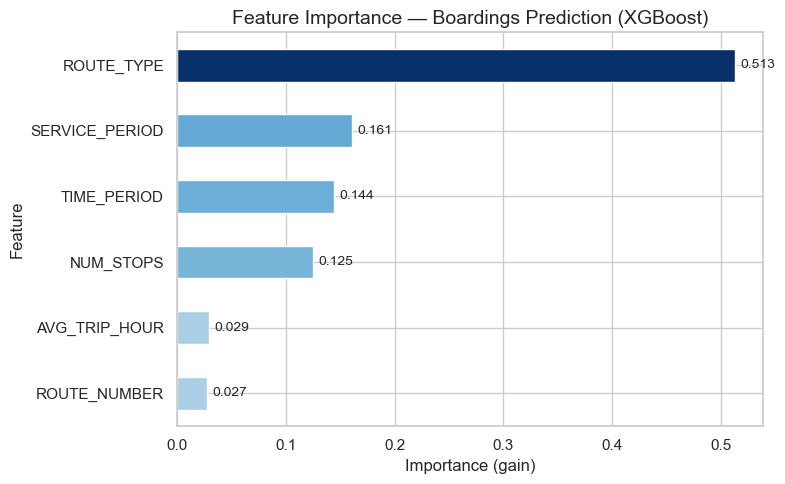

In [7]:
xgb_importance = pd.Series(
    results['XGBoost']['model'].feature_importances_,
    index=reg_features
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
norm_vals = xgb_importance.values / xgb_importance.values.max()
bar_colors = plt.cm.Blues(0.3 + 0.7 * norm_vals)
xgb_importance.plot(kind='barh', color=bar_colors, ax=ax)
ax.set_xlabel('Importance (gain)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature Importance — Boardings Prediction (XGBoost)', fontsize=14)
for i, v in enumerate(xgb_importance.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('figures/reg_3_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

**Transit Insight:** If `ROUTE_NUMBER` dominates, the specific route is the strongest predictor — some routes inherently carry more passengers regardless of time. If `NUM_STOPS` is high, routes serving more stops accumulate more boardings, suggesting route length matters. If `SERVICE_PERIOD` is important, weekday vs weekend differences are a major driver of demand.

### Visualization 4: SHAP Summary Plot (Model Explainability)

Computing SHAP values (sampling 2,000 test points)...


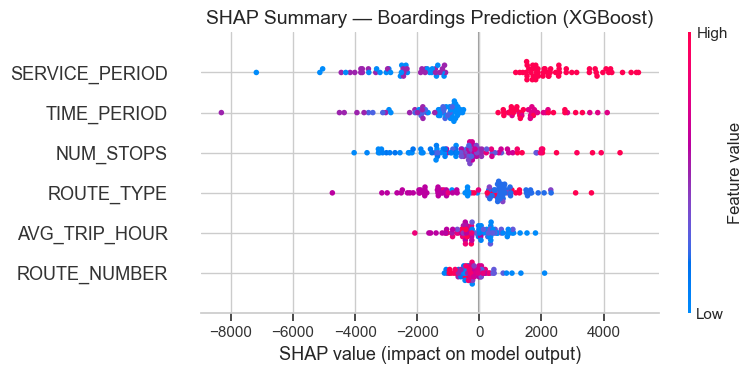

SHAP computation complete.


In [8]:
print('Computing SHAP values (sampling 2,000 test points)...')
shap_n = min(2000, len(X_test))
X_shap = X_test.sample(n=shap_n, random_state=42)

explainer = shap.TreeExplainer(results['XGBoost']['model'])
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=reg_features, show=False)
plt.title('SHAP Summary — Boardings Prediction (XGBoost)', fontsize=14)
plt.tight_layout()
plt.savefig('figures/reg_4_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print('SHAP computation complete.')

**Transit Insight (Model Explainability):** SHAP values show **how each feature pushes the predicted route-level boardings up or down**. Positive SHAP values (right) increase predicted boardings; negative values (left) decrease them. For example, if certain `ROUTE_NUMBER` values consistently push predictions right, those are high-demand routes that VTA should prioritize for capacity expansion.

### Visualization 5: Correlation Heatmap (Redundancy & PCA Concepts)

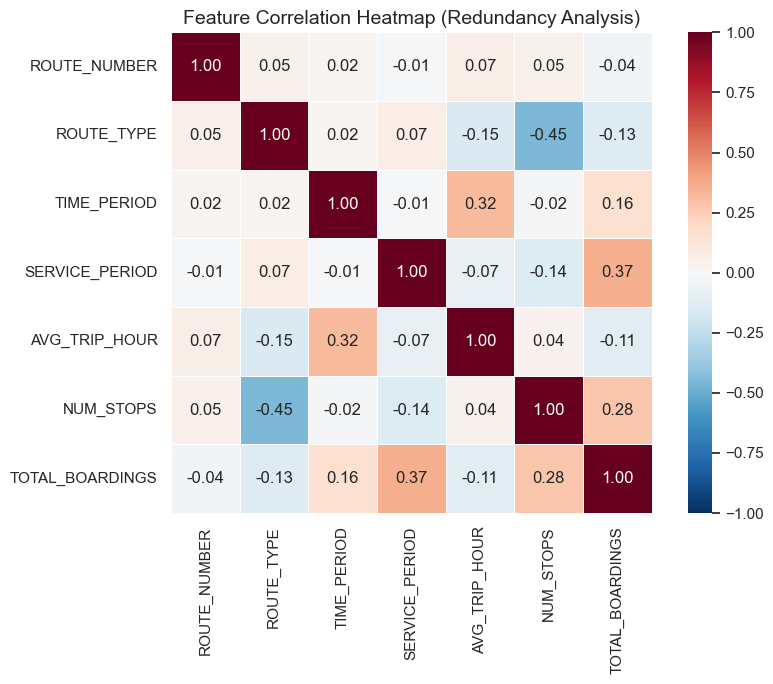

In [9]:
corr_cols = reg_features + ['TOTAL_BOARDINGS']
corr_matrix = df_enc[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap (Redundancy Analysis)', fontsize=14)
plt.tight_layout()
plt.savefig('figures/reg_5_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

**Transit Insight:** The correlation heatmap reveals **redundancy between features**. High correlation between two features means they carry similar information — one could be dropped without losing predictive power. The bottom row shows each feature's correlation with TOTAL_BOARDINGS (our target) — features with stronger correlation are naturally better predictors. This analysis also motivates dimensionality reduction techniques like PCA when features are highly collinear.

### Visualization 6: Model Comparison

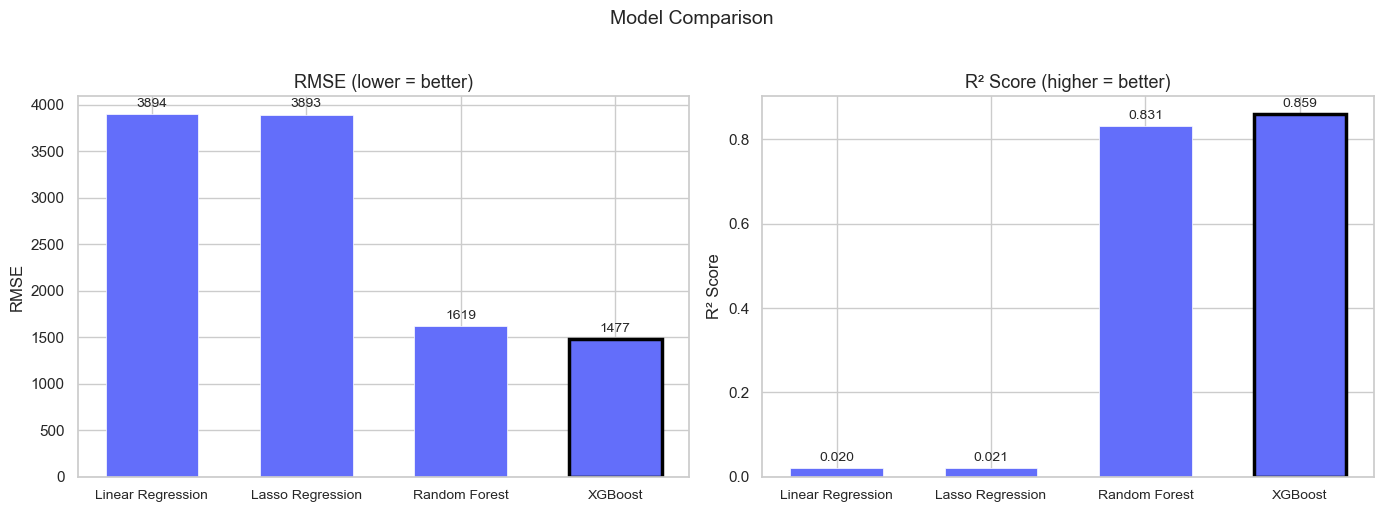

In [10]:
model_names = list(results.keys())
rmses = [results[m]['rmse'] for m in model_names]
r2s = [results[m]['r2'] for m in model_names]

x_pos = np.arange(len(model_names))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

edge_colors = ['black' if m == best_name else 'white' for m in model_names]
edge_widths = [2.5 if m == best_name else 0.5 for m in model_names]

bars1 = ax1.bar(x_pos, rmses, color='#636EFA', width=0.6, edgecolor=edge_colors, linewidth=edge_widths)
ax1.bar_label(bars1, fmt='%.0f', padding=3, fontsize=10)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(model_names, fontsize=10)
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_title('RMSE (lower = better)', fontsize=13)

bars2 = ax2.bar(x_pos, r2s, color='#636EFA', width=0.6, edgecolor=edge_colors, linewidth=edge_widths)
ax2.bar_label(bars2, fmt='%.3f', padding=3, fontsize=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(model_names, fontsize=10)
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_title('R² Score (higher = better)', fontsize=13)

fig.suptitle('Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/reg_6_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

**Transit Insight:** The comparison shows how model complexity affects route-level boarding predictions. **Lasso** performs automatic feature selection — if it drops a feature, that feature isn't useful for predicting boardings. If tree-based models (RF, XGBoost) dramatically outperform Linear/Lasso, it confirms **non-linear demand patterns** that simple linear models cannot capture. The best model would be deployed for VTA's route-level demand forecasting.

## Summary: Key Findings & Limitations

### Strengths
- Route-level aggregation aligns with how VTA makes scheduling decisions
- Features (route, time period, service day) are directly actionable for transit planners
- SHAP reveals which routes and time periods drive the highest demand

### Limitations
- Aggregation reduces dataset size, which may limit model generalization
- Model does not capture external demand shocks (events, weather, holidays)
- October data only — seasonal variation not represented

### Transit Recommendations
- Use the best model to forecast route-level demand for schedule optimization
- High-importance routes identified by SHAP should be prioritized for service frequency increases
- Combine with crowding classification to build a full demand + capacity planning system

In [11]:
print('=' * 65)
print('REGRESSION SUMMARY')
print('=' * 65)
print(f'\nTask: Predict Route-Level Total Boardings')
print(f'Target: TOTAL_BOARDINGS per route × time period × service day')
print(f'Features: {reg_features}')
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'\n{"Model":<25} {"RMSE":>10} {"MAE":>10} {"R\u00b2":>8}')
print('-' * 55)
for name, res in results.items():
    marker = ' <-- BEST' if name == best_name else ''
    print(f'{name:<25} {res["rmse"]:>10.3f} {res["mae"]:>10.3f} {res["r2"]:>8.4f}{marker}')
print(f'\n6 ML visualizations generated.')
print(f'Total time: {ml_time:.1f}s')

REGRESSION SUMMARY

Task: Predict Route-Level Total Boardings
Target: TOTAL_BOARDINGS per route × time period × service day
Features: ['ROUTE_NUMBER', 'ROUTE_TYPE', 'TIME_PERIOD', 'SERVICE_PERIOD', 'AVG_TRIP_HOUR', 'NUM_STOPS']
Train: 404 | Test: 101

Model                           RMSE        MAE       R²
-------------------------------------------------------
Linear Regression           3894.099   3077.308   0.0203
Lasso Regression            3893.405   3077.256   0.0206
Random Forest               1618.991    976.722   0.8307
XGBoost                     1477.474    796.073   0.8590 <-- BEST

6 ML visualizations generated.
Total time: 1.0s
